## Imports and Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pickle as pk
import sys
import sailfish
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
import cmocean, cmasher
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MultipleLocator
from scipy.signal import lombscargle
import glob, os
import matplotlib.gridspec as gridspec

from sailfish.physics.cooling import ShakuraSunyaevDisk, cgs, PlanckSpectrum
from sailfish.physics.kepler import OrbitalState, PointMass
from Diagnostics import DavidTimeseries, eccentric_anomaly
transparent_black = mcolors.LinearSegmentedColormap.from_list("transparent_black", [(0, (1, 1, 1, 0)), (1, (0, 0, 0, 1))])

text_width   = 5.0 #6.8
column_width = 2.4 #3.3
def configure_matplotlib():
    plt.rc('xtick' , labelsize=8)
    plt.rc('ytick' , labelsize=8)
    plt.rc('axes'  , labelsize=8)
    plt.rc('legend', fontsize=8)
    plt.rc('font', family='DejaVu Sans', size=8)
    plt.rc('text', usetex=True)
    plt.rcParams.update({
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 2,
        "ytick.major.width": 2,
        "xtick.color": "black",
        "ytick.color": "black",
    })
    plt.rcParams.update({
        "axes.linewidth": 2,  # default is 0.8
    })
configure_matplotlib()

def load_checkpoint(filename, require_solver=None):
    with open(filename, "rb") as f:
        chkpt = pk.load(file=f)
    return chkpt

def ViscousTime(r, Mach, alpha):
    return (5/24/np.pi) * (r**1.6) * Mach**2 / alpha

def EddingtonFraction(Mach, M, r, gamma=5/3, alpha=0.1, eta=0.1):
    kappa_es = 0.4 # in cgs
    rg       = cgs['G'] * M / cgs['c'] / cgs['c']
    c1       = np.sqrt(4 * cgs['sigmab'] * kappa_es * cgs['c']**2 * cgs['mp']**4 / (cgs['kb']**4) / 3)
    c2       = (0.1**0.5) * (5/3)**(-2) * (2530*rg)**(-0.25) * (cgs['G'] * 8e6*cgs['msun'])**0.75 * 1e-5 * 0.1
    print('Eddington Fraction (Coefficient): ', c1 * c2/np.sqrt(2))
    return c1 * c2 * (alpha/0.1)**0.5 * (gamma/(5/3))**(-2) * (r/(2530))**(-0.25) * (M/(8e6*cgs['msun']))**0.75 * (Mach/10)**(-5) * (eta/0.1) / np.sqrt(2)

print('Viscous time : ',ViscousTime(r=7, Mach=40, alpha=0.1))


Viscous time :  23871.83129582782


## Disk Remapping Parameters

In [2]:
Mach10_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 10,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach20_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 20,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach40_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 40,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach80_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 80,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach160_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 160,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

print('=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===')
print('-----------------+-----------------------------------------------------------+')
print('                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |')
print('-----------------+-----------------------------------------------------------+')
print(f"Mdrop values     | {Mach10_Remapping:.3e} | {Mach20_Remapping:.3e} | {Mach40_Remapping:.3e} | {Mach80_Remapping:.3e} | {Mach160_Remapping:.3e} |")
print(f"A values         | {1/Mach10_Remapping:.3e} | {1/Mach20_Remapping:.3e} | {1/Mach40_Remapping:.3e} | {1/Mach80_Remapping:.3e} | {1/Mach160_Remapping:.3e} |")

=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===
-----------------+-----------------------------------------------------------+
                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |
-----------------+-----------------------------------------------------------+
Mdrop values     | 6.456e-08 | 2.066e-06 | 6.611e-05 | 2.116e-03 | 6.770e-02 |
A values         | 1.549e+07 | 4.840e+05 | 1.513e+04 | 4.727e+02 | 1.477e+01 |


## Density Map Colour Schemes

In [4]:
data        = {}
dir         = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/'
Checkpoints = ['Fixed_e/e00Mach10/chkpt.0240.pk'      , 'Fixed_e/e03Mach10/chkpt.0240.pk', 'Fixed_e/e06Mach10/chkpt.0240.pk',
               'Sweeps/Mach20/FixedHLLE/chkpt.0200.pk', 'Fixed_e/e03Mach20/chkpt.0160.pk', 'Fixed_e/e06Mach20/chkpt.0175.pk',
               'Fixed_e/e00Mach40/chkpt.0700.pk'      , 'Fixed_e/e03Mach40/chkpt.0400.pk', 'Fixed_e/e06Mach40/chkpt.0500.pk']
Names       = ['M10_e00'                , 'M10_e03'                , 'M10_e06',
               'M20_e00'                , 'M20_e03'                , 'M20_e06',
               'M40_e00'                , 'M40_e03'                , 'M40_e06']

# Update Mach 20 e06 (ASTRO)
# Rerun Mach 20 e00 (ASTRO)

for index in range(0, len(Checkpoints)):
    data[Names[index]] = load_checkpoint(dir + Checkpoints[index])


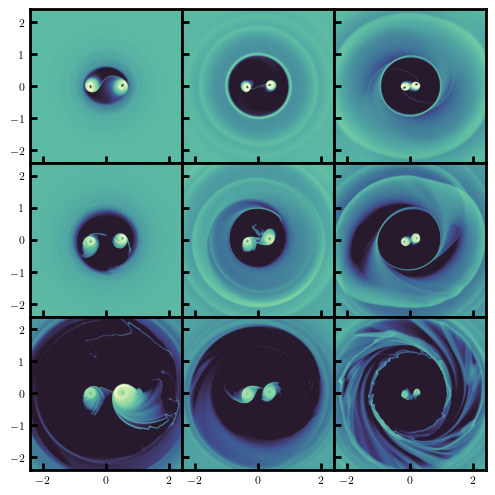

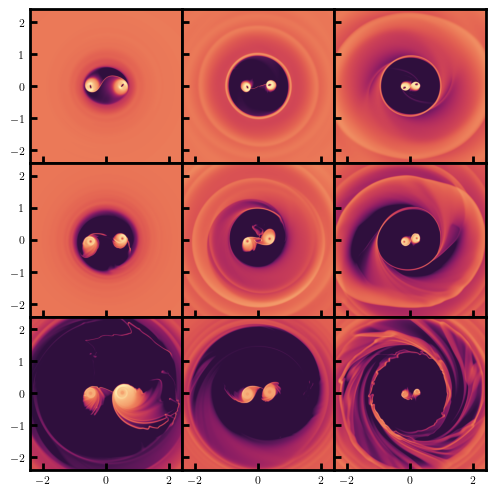

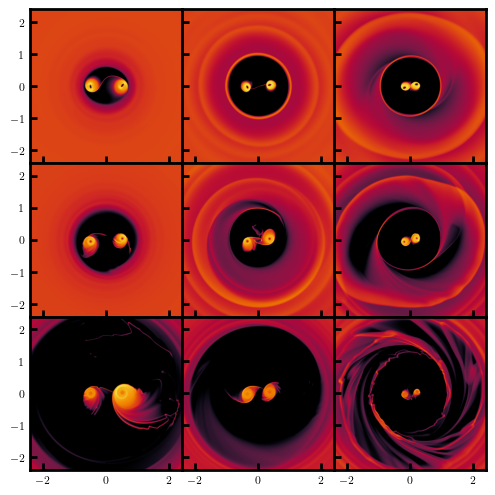

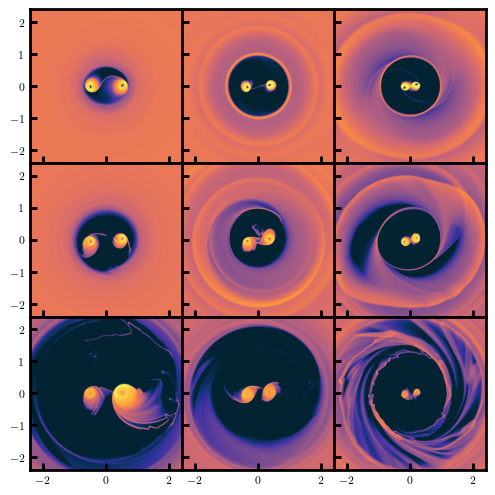

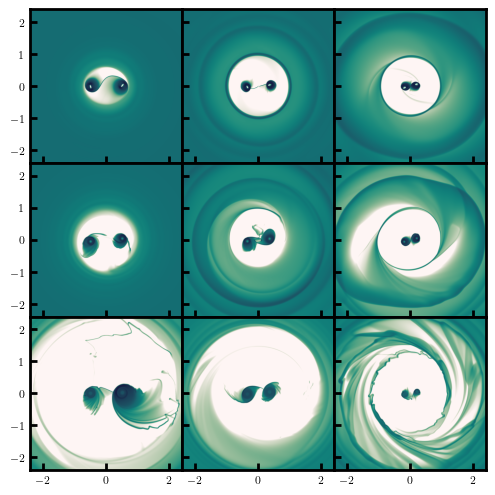

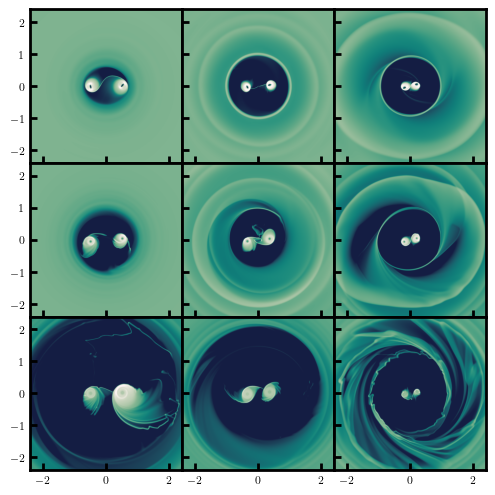

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(0, len(Checkpoints)):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.deep_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.matter_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-6.7,
                    vmax=-4,
                    cmap=cmasher.ember,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.thermal,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.tempo,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


/tmp/ipykernel_4169906/3939192128.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


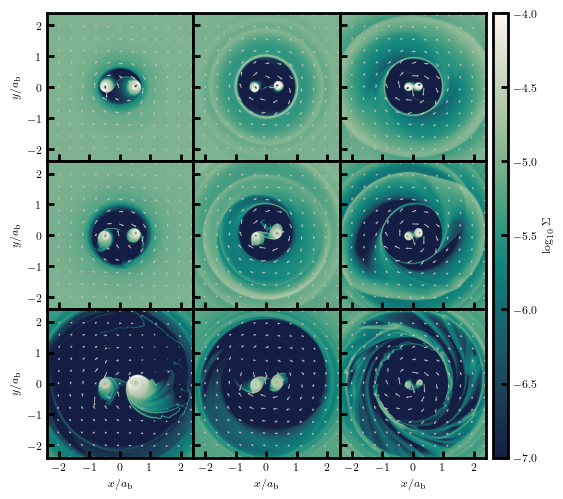

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


def VMap(ax, mesh, Radius, Vx, Vy, Number_of_Vectors=10):
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])

    try:
        rescaled_x = [ix for ix in x if np.abs(ix) < Radius]
        xmin, xmax = np.where(x == np.min(rescaled_x))[0][0], np.where(x == np.max(rescaled_x))[0][0]
    except:
        rescaled_x = x
        xmin, xmax = 0,len(x)-1

    Sampling = (xmax-xmin)//Number_of_Vectors

    if len(rescaled_x)//Number_of_Vectors == 0:
        Sampling = 1

    X, Y       = np.meshgrid(x[xmin:xmax:Sampling], y[xmin:xmax:Sampling])

    Vx_sampled = Vx[xmin:xmax:Sampling, xmin:xmax:Sampling] 
    Vy_sampled = Vy[xmin:xmax:Sampling, xmin:xmax:Sampling]
    ax.quiver(X, Y, Vx_sampled, Vy_sampled, width=0.006, angles='xy', scale_units='xy', scale=8, color = 'silver', headlength=3, headaxislength=2.,)


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]

    mesh   = chkpt["mesh"]
    SS73   = chkpt["SS73"]
    Sigma  = chkpt["solution"][:, :, 0].T * SS73.Mdrop**(3./5.)
    Vx     = chkpt["solution"][:, :, 1].T
    Vy     = chkpt["solution"][:, :, 2].T

    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7.0,
                    vmax=-4.0,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')
    VMap(ax=ax, mesh=mesh, Radius=2.4, Vx=Vx, Vy=Vy, Number_of_Vectors=12)

cax = inset_axes(axes[1, 2],  # anchor to middle-right panel
                 width="10%",
                 height="300%",  # spans 3 panels
                 loc="center right",
                 bbox_to_anchor=(0.15, 0, 1, 1),
                 bbox_transform=axes[1, 2].transAxes,
                 borderpad=0)

for ax in axes_flat:
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

cbar = fig.colorbar(cm, cax=cax)
cbar.set_label(r'$\log_{10} \Sigma$')
col_labels = [r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$']
row_labels = [r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$']

for col in range(3):
    axes[2, col].set_xlabel(col_labels[col])

for row in range(3):
    axes[row, 0].set_ylabel(row_labels[row])


plt.tight_layout()
plt.savefig('DensityMaps.png', dpi = 400, bbox_inches='tight')

## Sweep Plotting

In [5]:
def ComputeBinnedStats(times, field, Averaging_Window):
    """Return bin centers, means, and 1-sigma standard deviations."""
    num_bins    = int(np.ceil((times[-1] - times[0]) / Averaging_Window))
    bin_edges   = np.linspace(times[0], times[-1], num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_means   = np.zeros(num_bins)
    bin_stds    = np.zeros(num_bins)

    for i in range(num_bins):
        bin_mask = (times >= bin_edges[i]) & (times < bin_edges[i + 1])
        bin_data = field[bin_mask]
        if len(bin_data) > 1:
            bin_means[i] = np.mean(bin_data)
            bin_stds[i]  = np.std(bin_data)
        elif len(bin_data) == 1:
            bin_means[i] = bin_data[0]
            bin_stds[i]  = np.nan
        else:
            bin_means[i] = np.nan
            bin_stds[i]  = np.nan

    return bin_centers, bin_means, bin_stds

def ComputeAdotEdot(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    Final_Orbits        = ts.eccentricity[ts.eccentricity>0.0001]

    primary, secondary  = ts.pointmasses
    m1, m2              = primary.mass, secondary.mass
    M, G                = m1 + m2, 1.0
    q                   = m2 / m1                                            # mass ratio
    mu                  = m1 * m2 / M                                        # reduced mass
    Torque              = -(np.array(ts.torque_g[-len(Final_Orbits):]) + np.array(ts.torque_a[-len(Final_Orbits):])) / M_dot_0
    Power               = -(np.array(ts.power_g[-len(Final_Orbits):] ) + np.array(ts.power_a[-len(Final_Orbits):] )) / M_dot_0
    Accretion_1         = -(np.array(ts.mdot1[-len(Final_Orbits):])) / M_dot_0
    Accretion_2         = -(np.array(ts.mdot2[-len(Final_Orbits):])) / M_dot_0
    Mdot                = Accretion_1 + Accretion_2                          # total mass accretion rate
    a                   = np.array(ts.semimajor_axis[-len(Final_Orbits):])   # = a_rel (relative orbit semi-major axis)
    e                   = np.array(ts.eccentricity[-len(Final_Orbits):])
    E_Anomaly           = np.array([eccentric_anomaly(2*np.pi*Final_Orbits[ind], e[ind], a[ind], M) for ind in range(len(Final_Orbits))])
    cosE                = np.cos(E_Anomaly)
    ecosE               = e * cosE
    r_binary            = a * (1 - ecosE)                                    # binary separation
    E                   = - G * M * mu / (2*a)
    L                   = mu * np.sqrt(G * M * a * (1 - e**2))
    mudot               = Mdot * mu / M + (1 - q) * (Accretion_2 - q * Accretion_1) * mu / q / M
    v2                  = G * M * (2 / r_binary - 1 / a)
    Edot                = -0.5*mudot*v2 - G*M*mudot/r_binary - G*Mdot*mu / r_binary + Power
    Ldot                = Torque 
    adot                = Mdot / M + mudot / mu - Edot / E
    edot                = ((1-e**2) / (2*e+1e-5)) * (2*Mdot/M + 3*mudot/mu - 2*Ldot/L - Edot/E)
    return e, adot, edot

def ComputeLightcurves(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    n_final             = len(ts.eccentricity[ts.eccentricity > 0.0001])
    t_orbits            = np.array(ts.time[-n_final:])          # orbit count — correct time axis for LS

    return (
        ts.infared[-n_final:] / M_dot_0,
        ts.optical[-n_final:] / M_dot_0,
        ts.uv[-n_final:]      / M_dot_0,
        t_orbits
    )

#Mach10Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach10/n5000/chkpt.0550.pk')
#Mach20Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/n20000/chkpt.2367.pk')
Mach10Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Prograde/CoolingSweep/chkpt.1124.pk')
Mach20Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/FixedHLLE/chkpt.0639.pk')

Mach10_e, Mach10_adot, Mach10_edot = ComputeAdotEdot(Mach10Sweep)
Mach20_e, Mach20_adot, Mach20_edot = ComputeAdotEdot(Mach20Sweep)

Mach10_infared, Mach10_optical, Mach10_uv, Mach10_t = ComputeLightcurves(Mach10Sweep)
Mach20_infared, Mach20_optical, Mach20_uv, Mach20_t = ComputeLightcurves(Mach20Sweep)


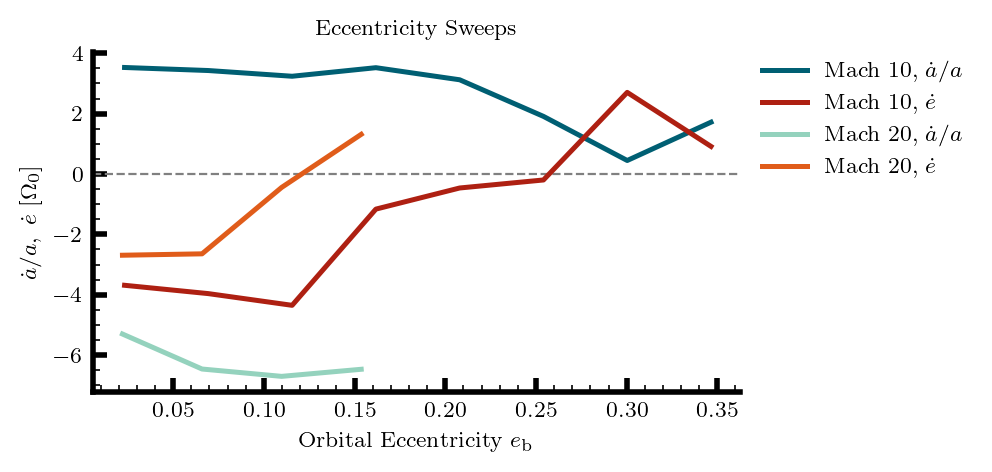

In [6]:
fig, ax  = plt.subplots(figsize=[text_width, column_width],  dpi=200)
savename = 'Sweep'

_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#6BAED6'  # medium cornflower blue

_edot_dark  = '#B2182B'  # deep crimson
_edot_light = '#EF8A62'  # warm salmon-orange


_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#74ADD1'  # sky blue

_edot_dark  = '#1A7B35'  # deep forest green
_edot_light = '#74C476'  # medium sage green


_adot_dark  = '#005F73'  # deep teal
_adot_light = '#94D2BD'  # pale teal

_edot_dark  = '#AE2012'  # deep brick red
_edot_light = '#E05C1A'  # amber-orange



Mach10_ea, Mach10_ma, _ = ComputeBinnedStats(Mach10_e, Mach10_adot, 0.05)
Mach10_ee, Mach10_me, _ = ComputeBinnedStats(Mach10_e, Mach10_edot, 0.05)
Mach20_ea, Mach20_ma, _ = ComputeBinnedStats(Mach20_e, Mach20_adot, 0.05)
Mach20_ee, Mach20_me, _ = ComputeBinnedStats(Mach20_e, Mach20_edot, 0.05)

ax.plot(Mach10_ea, Mach10_ma, linewidth=1.8, linestyle='solid', color=_adot_dark , label=r'Mach 10, $\dot{a}/a$', zorder=3)
ax.plot(Mach10_ee, Mach10_me, linewidth=1.8, linestyle='solid', color=_edot_dark , label=r'Mach 10, $\dot{e}$',   zorder=3)
ax.plot(Mach20_ea, Mach20_ma, linewidth=1.8, linestyle='solid', color=_adot_light, label=r'Mach 20, $\dot{a}/a$', zorder=3)
ax.plot(Mach20_ee, Mach20_me, linewidth=1.8, linestyle='solid', color=_edot_light, label=r'Mach 20, $\dot{e}$',  zorder=3)

# ax.scatter(Mach10_ea, Mach10_ma, color=_adot_dark,  s = 10)
# ax.scatter(Mach10_ee, Mach10_me, color=_edot_dark,  s = 10)
# ax.scatter(Mach20_ea, Mach20_ma, color=_adot_light, s = 10)
# ax.scatter(Mach20_ee, Mach20_me, color=_edot_light, s = 10)

# ax.scatter(0.0, -10.14, color=_adot_dark, marker='x', s=30, zorder=4)
# ax.scatter(0.3, -13.16, color=_adot_dark, marker='x', s=30, zorder=4)
# ax.scatter(0.6, -17.81, color=_adot_dark, marker='x', s=30, zorder=4)
# ax.scatter(0.3,  -2.59, color=_edot_dark, marker='x', s=30, zorder=4)
# ax.scatter(0.6,  -0.84, color=_edot_dark, marker='x', s=30, zorder=4, label = 'Fixed e')

ax.autoscale()
_ylo, _yhi = ax.get_ylim()

ax.set_ylim(_ylo, _yhi)   
ax.axhline(y=0, color='0.5', linewidth=0.8, linestyle='--', zorder=2)

ax.set_xlabel('Orbital Eccentricity $e_\mathrm{b}$')
ax.set_ylabel(r'$\dot{a}/a,\ \dot{e}\ [\Omega_0]$')
ax.set_title(r'Eccentricity Sweeps', fontsize=8)
#ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
ax.minorticks_on()
ax.tick_params(which='minor', length=2.5, direction='in')
fig.tight_layout()


plt.tight_layout()
plt.savefig('Sweep', dpi=300)

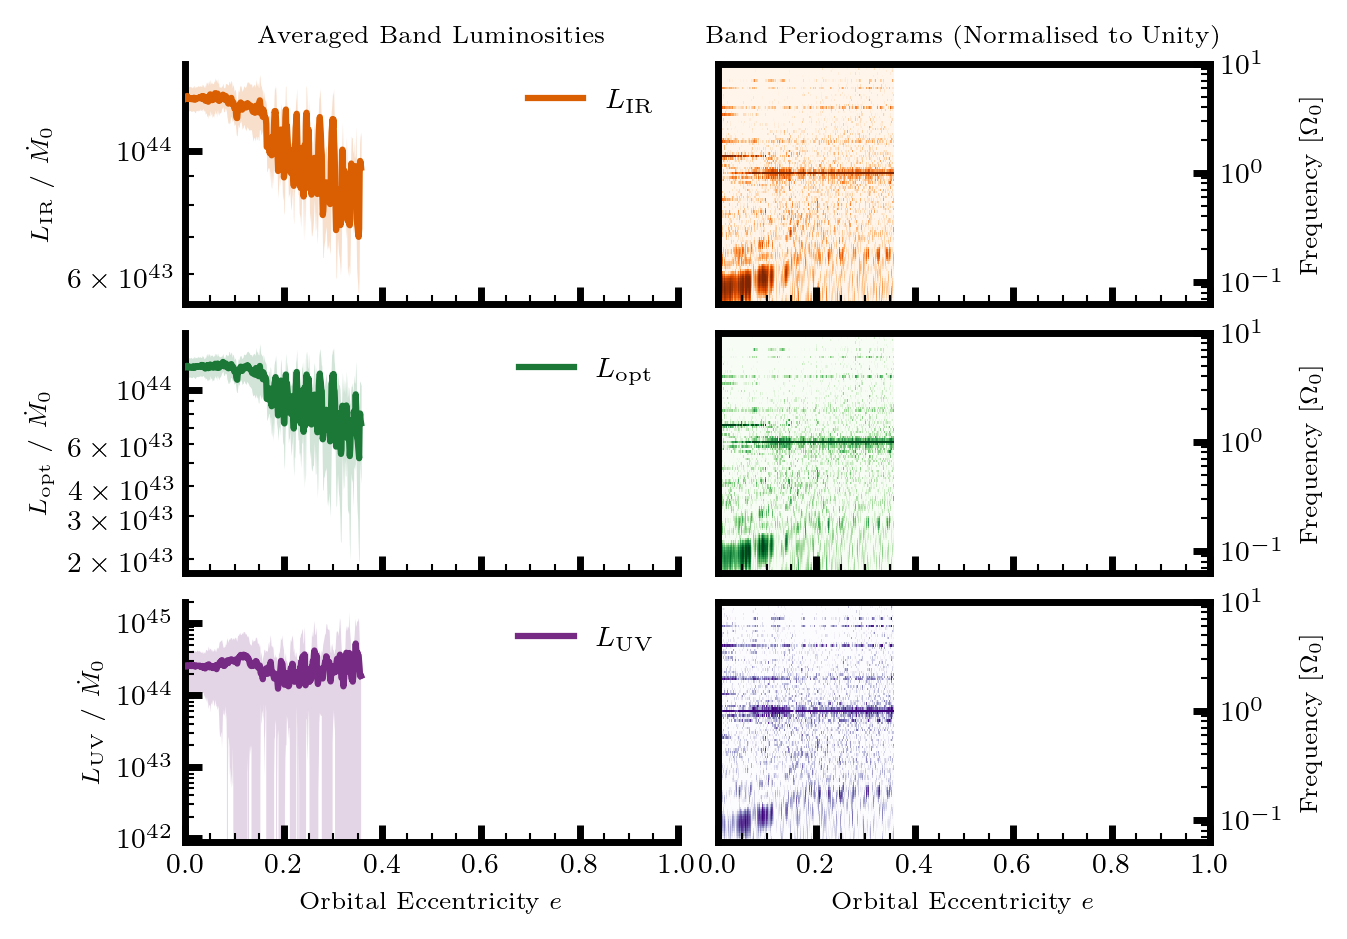

In [35]:
Mach20 = True

if Mach20:
    infared, optical, uv, e, t = Mach20_infared, Mach20_optical, Mach20_uv, Mach20_e, Mach20_t
else:
    infared, optical, uv, e, t = Mach10_infared, Mach10_optical, Mach10_uv, Mach10_e, Mach10_t

delta_e = 0.001
e_f     = e[-1]

# --- EM panels: L(e) line (left) + 2D LS spectrogram P(e, f) (right) ---
_bands = [
    (infared,  r'$L_\mathrm{IR}$',  r'$L_\mathrm{IR}\ /\ \dot{M}_0$',  '#D95F02', 'Oranges'),
    (optical,  r'$L_\mathrm{opt}$', r'$L_\mathrm{opt}\ /\ \dot{M}_0$', '#1B7837', 'Greens' ),
    (uv     ,  r'$L_\mathrm{UV}$',  r'$L_\mathrm{UV}\ /\ \dot{M}_0$',  '#762A83', 'Purples'),
]

# eccentricity bins for the 2D spectrogram 
_n_e      = int(e_f / delta_e)
_e_edges  = np.linspace(0.0, e_f, _n_e + 1)
_e_ctrs   = 0.5 * (_e_edges[:-1] + _e_edges[1:])
_freq_2d  = np.logspace(-1.2, 1, 100)           # cycles / orbit, 0.1 – 10
_omega_2d = 2.0 * np.pi * _freq_2d
_min_samp = 5                                    # min points per bin for reliable LS

# pre-compute L(e) stats and per-bin periodograms for each band
_band_stats = []
for lum, band_label, ylabel, color, cmap in _bands:
    ec, lm, ls = ComputeBinnedStats(e, lum, delta_e)
    power_2d   = np.full((_n_e, len(_freq_2d)), np.nan)

    for j in range(_n_e):
        mask = (e >= _e_edges[j]) & (e < _e_edges[j + 1])
        if mask.sum() >= _min_samp:
            t_bin   = t[mask]
            sig_bin = lum[mask] - np.mean(lum[mask])
            var_bin = np.var(sig_bin)
            if var_bin > 0:
                p          = lombscargle(t_bin, sig_bin, _omega_2d)
                p         /= var_bin          # Scargle-normalised LS power
                med        = np.median(p)
                if med > 0:
                    p /= med                  # excess above noise floor; stable w.r.t. freq resolution
                power_2d[j] = p

    _band_stats.append((ec, lm, ls, power_2d, band_label, ylabel, color, cmap))

fig2 = plt.figure(figsize=[text_width, text_width * 0.75], dpi = 250)
gs   = fig2.add_gridspec(3, 2, width_ratios=[1.0, 1.0],
                            hspace=0.12, wspace=0.08,
                            left=0.10, right=0.92, top=0.93, bottom=0.10)

ax_lum_ref = None
ax_per_ref = None
last_im    = None

for i, (ec, lm, ls, power_2d, band_label, ylabel, color, cmap) in enumerate(_band_stats):

    ax_lum = fig2.add_subplot(gs[i, 0], sharex=ax_lum_ref)
    ax_per = fig2.add_subplot(gs[i, 1], sharex=ax_per_ref)
    if ax_lum_ref is None:
        ax_lum_ref = ax_lum
    if ax_per_ref is None:
        ax_per_ref = ax_per

    # left: mean luminosity ± 1σ vs eccentricity
    ax_lum.fill_between(ec, lm - ls, lm + ls,
                            color=color, alpha=0.2, linewidth=0, zorder=1)
    ax_lum.plot(ec, lm, linewidth=1.8, color=color, label=band_label, zorder=3)
    ax_lum.set_yscale('log')
    ax_lum.set_ylabel(ylabel, fontsize=7)
    ax_lum.set_xlim(0.0, 1.0)
    ax_lum.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
    ax_lum.spines['top'].set_visible(False)
    ax_lum.spines['right'].set_visible(False)
    ax_lum.tick_params(which='both', top=False, right=False)
    ax_lum.minorticks_on()
    ax_lum.tick_params(which='minor', length=2.5, direction='in')
    
    if i < 2:
        ax_lum.tick_params(labelbottom=False)

    from matplotlib.colors import LogNorm
    valid   = power_2d[np.isfinite(power_2d) & (power_2d > 0)]
    vmin    = 1.0    # or just fix at 1.0 since you median-normalised
    vmax    = np.percentile(valid, 99)   # captures the bulk without being blown out by spikes
    norm    = LogNorm(vmin=vmin, vmax=vmax)
    im      = ax_per.pcolormesh(_e_ctrs, _freq_2d, power_2d.T, cmap=cmap, shading='auto', rasterized=True, norm=norm)
    last_im = im
    ax_per.set_yscale('log')
    ax_per.set_ylim(_freq_2d[0], _freq_2d[-1])
    ax_per.set_xlim(0.0, 1.0)
    ax_per.set_ylabel(r'Frequency $[\Omega_0]$', fontsize=7)
    ax_per.yaxis.set_label_position('right')
    ax_per.yaxis.tick_right()
    ax_per.tick_params(which='both', top=False, left=False)
    ax_per.minorticks_on()
    ax_per.tick_params(which='minor', length=2.5, direction='in')

    if i == 0:
        ax_lum.set_title('Averaged Band Luminosities', fontsize=7)
        ax_per.set_title('Band Periodograms (Normalised to Unity)', fontsize=7)

    if i == 2:
        ax_lum.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
        ax_per.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
    else:
        ax_lum.tick_params(labelbottom=False)
        ax_per.tick_params(labelbottom=False)


plt.savefig('Mach20_Emission.png', bbox_inches='tight')


## Disk Profiles

In [34]:
Load_in = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Fixed_e/e06Mach40/chkpt.0200.pk'

if os.path.isdir(Load_in):
    # Time average
    checkpoint_files = sorted(glob.glob(Load_in + 'chkpt.*.pk'))
    sigma_sum        = None
    for f in checkpoint_files:
        chkpt = load_checkpoint(f)
        sigma = chkpt["solution"][:, :, 0].T
        vx    = chkpt['solution'][:, :, 1].T
        vy    = chkpt['solution'][:, :, 2].T
        press = chkpt["solution"][:, :, 3].T 
        if sigma_sum is None:
            sigma_sum = sigma
            press_sum = press
            vx_sum    = vx
            vy_sum    = vy
        else:
            sigma_sum += sigma
            press_sum += press
            vx_sum    += vx
            vy_sum    += vy
            print(f, end='\r')
    print()

    Sigma    = sigma_sum / len(checkpoint_files)
    Pressure = press_sum / len(checkpoint_files)
    Vx       = vx_sum    / len(checkpoint_files)
    Vy       = vy_sum    / len(checkpoint_files)
    mesh     = chkpt["mesh"]

else:
    # Single snapshot
    chkpt      = load_checkpoint(Load_in)
    mesh       = chkpt["mesh"]
    Sigma      = chkpt["solution"][:, :, 0].T 
    Vx         = chkpt['solution'][:, :, 1].T
    Vy         = chkpt['solution'][:, :, 2].T
    Pressure   = chkpt["solution"][:, :, 3].T 

# Assign useful properties
SS73       = chkpt["SS73"]
gamma      = chkpt['model_parameters']['gamma_law_index']
cs         = (gamma * Pressure / Sigma)**0.5
ni, nj     = mesh.shape
x          = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
y          = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
X, Y       = np.meshgrid(x, y, indexing="xy")
Nbins      = int(100)
RadialBins = np.linspace(0.8, mesh.x1, Nbins)
Sigma     *= SS73.surface_density_coefficient # in units of Mb/a0^2
radius     = np.sqrt( X**2 +  Y**2)
Radius     = RadialBins[1:]
speed      = np.sqrt(Vx**2 + Vy**2)
v_dot_v    = speed**2
v_dot_r    = Vx*X + Vy*Y
vr         = (Vx * X + Vy * Y) / radius
ang_mom    = X * Vy - Y * Vx
vphi       = ang_mom / radius
ex         = (v_dot_v * X - v_dot_r * Vx) - X / radius
ey         = (v_dot_v * Y - v_dot_r * Vy) - Y / radius
e          = np.sqrt(ex**2 + ey**2)
mach       = speed/cs
f          = 2*np.pi*radius * Sigma * vr / SS73.Mdot_inf
DiskStats  = {'MedianV' : [], 'MinV' : [], 'MaxV' : [], 'MedianE': [], 'MinE': [], 'MaxE': [], 'MedianD': [], 'MinD': [], 'MaxD': [], 'MedianM': [], 'MinM': [], 'MaxM': [], 
              'MedianVr': [], 'MinVr': [], 'MaxVr': [], 'Medianl': [], 'Minl': [], 'Maxl': []}

def SaveBinStats(dictname, keys, args):
     for (key, arg) in zip(keys, args):
          dictname[key].append(arg)

for i in range(len(RadialBins)-1):

     # Azimuthally average 
     mask           = (RadialBins[i] < radius) & (radius < RadialBins[i+1])
     N              = np.sum(mask)
     speed_mask     = speed[mask]
     e_mask         = e[mask]
     density_mask   = Sigma[mask]
     mach_mask      = mach[mask]
     vr_mask        = vr[mask]
     l_mask         = ang_mom[mask]

     SaveBinStats(
          DiskStats,
          ['MedianV', 'MinV', 'MaxV', 'MedianE', 'MinE', 'MaxE', 'MedianD', 'MinD', 'MaxD', 'MedianM', 'MinM', 'MaxM', 'MedianVr', 'MinVr', 'MaxVr', 'Medianl', 'Minl', 'Maxl'], 
          [np.median(speed_mask) , np.min(speed_mask)  , np.max(speed_mask),
          np.median(e_mask)      , np.min(e_mask)      , np.max(e_mask),
          np.median(density_mask), np.min(density_mask), np.max(density_mask), 
          np.median(mach_mask)   , np.min(mach_mask)   , np.max(mach_mask),
          np.median(vr_mask)     , np.min(vr_mask)     , np.max(vr_mask),
          np.median(l_mask)      , np.min(l_mask)      , np.max(l_mask)]
     )


# --- Minidisk Profile Analysis ---
RMinidisk          = 0.55
primary, secondary = chkpt['point_masses']
SinkRadius         = (primary.sink_radius,      secondary.sink_radius)
SoftRadius         = (primary.softening_length, secondary.softening_length)
RadialBins_md      = np.linspace(0, RMinidisk, int((RMinidisk / (mesh.x1 - mesh.x0)) * ni))
GMu_primary        = primary.mass
GMu_secondary      = secondary.mass

r_primary        = [X - primary.position_x,    Y - primary.position_y]
r_secondary      = [X - secondary.position_x,  Y - secondary.position_y]
V_primary        = [Vx - primary.velocity_x,   Vy - primary.velocity_y]
V_secondary      = [Vx - secondary.velocity_x, Vy - secondary.velocity_y]
primary_speed    = np.sqrt(V_primary[0]**2   + V_primary[1]**2)
secondary_speed  = np.sqrt(V_secondary[0]**2 + V_secondary[1]**2)
primary_radius   = np.sqrt(r_primary[0]**2   + r_primary[1]**2)
secondary_radius = np.sqrt(r_secondary[0]**2 + r_secondary[1]**2)

v_dot_v_primary   = primary_speed**2
v_dot_r_primary   = V_primary[0] * r_primary[0]  + V_primary[1] * r_primary[1]
ex_primary        = (v_dot_v_primary * r_primary[0]  - v_dot_r_primary * V_primary[0])  / GMu_primary  - r_primary[0]  / primary_radius
ey_primary        = (v_dot_v_primary * r_primary[1]  - v_dot_r_primary * V_primary[1])  / GMu_primary  - r_primary[1]  / primary_radius
e_primary         = np.sqrt(ex_primary**2  + ey_primary**2)
mach_primary      = primary_speed / cs
v_dot_v_secondary = secondary_speed**2
v_dot_r_secondary = V_secondary[0] * r_secondary[0] + V_secondary[1] * r_secondary[1]
ex_secondary      = (v_dot_v_secondary * r_secondary[0] - v_dot_r_secondary * V_secondary[0]) / GMu_secondary - r_secondary[0] / secondary_radius
ey_secondary      = (v_dot_v_secondary * r_secondary[1] - v_dot_r_secondary * V_secondary[1]) / GMu_secondary - r_secondary[1] / secondary_radius
e_secondary       = np.sqrt(ex_secondary**2 + ey_secondary**2)
mach_secondary    = secondary_speed / cs

keys              = ['MedianV','MinV','MaxV','MedianE','MinE','MaxE','MedianD','MinD','MaxD','MedianM','MinM','MaxM']
PrimaryMiniDisk   = {k: [] for k in keys}
SecondaryMiniDisk = {k: [] for k in keys}
for i in range(len(RadialBins_md) - 1):
    pm = (RadialBins_md[i] < primary_radius)   & (primary_radius   < RadialBins_md[i+1])
    sm = (RadialBins_md[i] < secondary_radius) & (secondary_radius < RadialBins_md[i+1])
    SaveBinStats(PrimaryMiniDisk, keys,
        [np.median(primary_speed[pm]),  np.min(primary_speed[pm]),  np.max(primary_speed[pm]),
         np.median(e_primary[pm]),      np.min(e_primary[pm]),      np.max(e_primary[pm]),
         np.median(Sigma[pm]),          np.min(Sigma[pm]),           np.max(Sigma[pm]),
         np.median(mach_primary[pm]),   np.min(mach_primary[pm]),   np.max(mach_primary[pm])])
    SaveBinStats(SecondaryMiniDisk, keys,
        [np.median(secondary_speed[sm]), np.min(secondary_speed[sm]), np.max(secondary_speed[sm]),
         np.median(e_secondary[sm]),     np.min(e_secondary[sm]),     np.max(e_secondary[sm]),
         np.median(Sigma[sm]),           np.min(Sigma[sm]),            np.max(Sigma[sm]),
         np.median(mach_secondary[sm]),  np.min(mach_secondary[sm]),  np.max(mach_secondary[sm])])




# Angular Momentum Flux Calculations
G         = Sigma * vr / SS73.surface_density_coefficient     # mass flux density through circles (per area)
dx, dy    = mesh.dx, mesh.dy
dA        = dx * dy
r_flat    = radius.ravel()
G_flat    = G.ravel()
vphi_flat = vphi.ravel()

r_min, r_max = 1.0, np.max(r_flat)/np.sqrt(2)
n_bins       = min(100, mesh.shape[0] // 4)
r_bins       = np.linspace(r_min, r_max, n_bins)
mdot_ring    = np.full(n_bins-1, np.nan)
r_centers    = 0.5*(r_bins[:-1] + r_bins[1:])

for k in range(n_bins-1):
    r0, r1 = r_bins[k], r_bins[k+1]
    mask   = (r_flat >= r0) & (r_flat < r1)
    if mask.any():
        dr           = (r1 - r0)
        mdot_ring[k] = -(G_flat[mask].sum() * dA) / dr  # ≈ - (1/dr) ∫_annulus Σ v_r dA

mdot_ring_norm = mdot_ring / SS73.Mdot_inf
alpha_visc     = chkpt['model_parameters']['alpha']
P0_flat        = Pressure.ravel()  # unscaled (code-unit) pressure
FJ0_ring       = np.full(n_bins - 1, np.nan)
FJ_total_ring  = np.full(n_bins - 1, np.nan)

for k in range(n_bins - 1):
    r0, r1 = r_bins[k], r_bins[k + 1]
    mask   = (r_flat >= r0) & (r_flat < r1)
    if mask.any():
        dr                = r1 - r0
        r_k               = r_centers[k]
        FJ_visc           = (3. / 2.) * alpha_visc * gamma * r_k * (P0_flat[mask].sum() * dA) / dr
        FJ0_ring[k]       = FJ_visc - mdot_ring[k] * np.sqrt(r_k)
        # F_J = 3π ν Σ l, ν Σ = α P r^{3/2}, l = r v_φ (not assumed Keplerian)
        FJ_total_ring[k]  = (3. / 2.) * alpha_visc * gamma * np.sum(P0_flat[mask] * r_flat[mask]**(3./2.) * vphi_flat[mask]) * dA / dr

FJ0_ring_norm      = FJ0_ring      / SS73.Mdot_inf  # in steady state ≈ ell0 (const)
FJ_total_ring_norm = FJ_total_ring / SS73.Mdot_inf

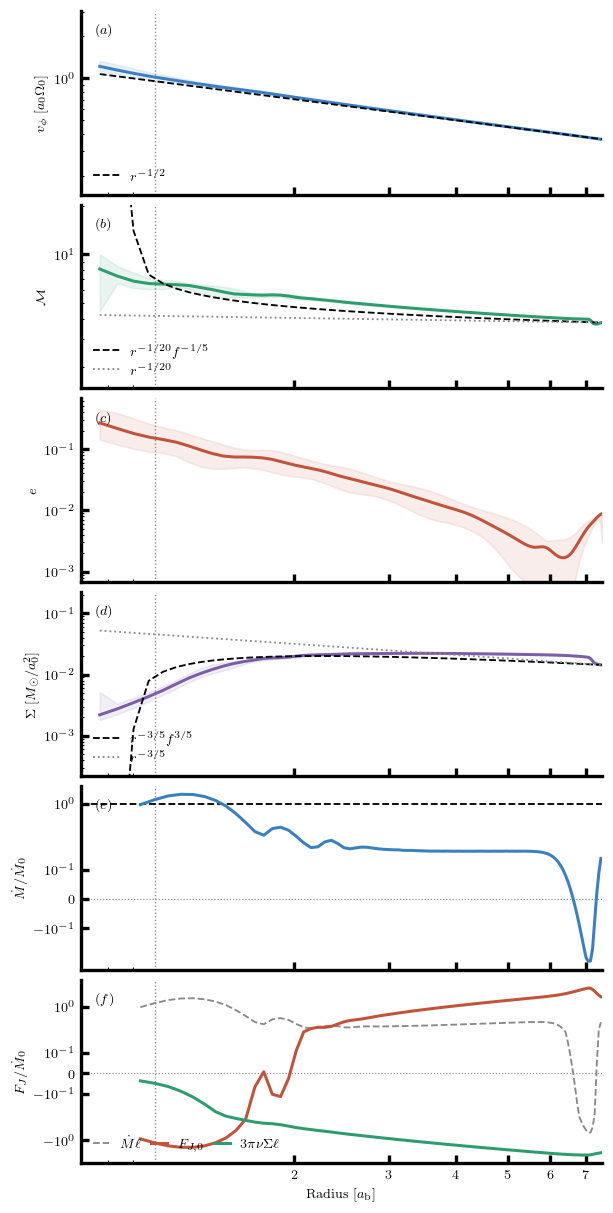

In [ ]:
cmap = cmocean.cm.tempo_r
colors = [cmap(i / 3) for i in range(1,3)]

_lw   = 1.8   # main data lines
_lw_r = 1.1   # reference/theory lines
_fa   = 0.10  # fill_between alpha

# ── Figure and gridspec ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(text_width, 2.0 * text_width), dpi=120)
fig.set_layout_engine('constrained')
gs   = fig.add_gridspec(4, 1, hspace=0.0)
axes = [fig.add_subplot(gs[i]) for i in range(4)]
ax1, ax2, ax3, ax4 = axes

# ── Shared x-axis (log, explicit tick positions) ─────────────────────────────
_xticks = [1, 2, 3, 4, 5, 6, 7]
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(RadialBins[0], mesh.x1)
    ax.set_xticks(_xticks)
    ax.set_xticklabels([str(v) for v in _xticks])
    ax.xaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.tick_params(labelbottom=False)
    ax.axvline(x=1.1, lw=0.8, ls=':', color=_c_ref, zorder=0)

ax4.tick_params(labelbottom=True)
ax4.set_xlabel(r'Radius $[a_\mathrm{b}]$')

# ── Panel labels ─────────────────────────────────────────────────────────────
for ax, lbl in zip(axes, 'abcdef'):
    ax.text(0.03, 0.93, f'$({lbl})$', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='left', zorder=4)


for i in [0, 1, 2]:
    # ── Reference f-factor profile ───────────────────────────────────────────────
    f0 = np.array([max(1e-8, 1.0 - ell0[i] / np.sqrt(r)) for r in Radius])

    # ── (a) Velocity ─────────────────────────────────────────────────────────────
    ax1.plot(Radius, DiskStats['MedianV'], color=colors[i], lw=_lw)
    ax1.fill_between(Radius, DiskStats['MinV'], DiskStats['MaxV'], color=colors[i], alpha=_fa)
    
    # ── (b) Mach number ───────────────────────────────────────────────────────────
    Mach_l0 = Radius**(-1/20) * f0**(-0.2)
    Mach_SS = Radius**(-1/20)
    ax2.plot(Radius, DiskStats['MedianM']                            , color=colors[i], lw=_lw)
    ax2.plot(Radius, DiskStats['MedianM'][-1] * Mach_l0 / Mach_l0[-1], color=colors[i], lw=_lw_r, ls='--', label=r'$r^{-1/20}f^{-1/5}$')
    ax2.plot(Radius, DiskStats['MedianM'][-1] * Mach_SS / Mach_SS[-1], color=colors[i], lw=_lw_r, ls=':' , label=r'$r^{-1/20}$')
    ax2.fill_between(Radius, DiskStats['MinM'], DiskStats['MaxM']    , color=colors[i], alpha=_fa)
    #ax2.set_ylim(0.4 * np.min(DiskStats['MedianM']), 2.5 * np.max(DiskStats['MedianM']))

    # ── (c) Eccentricity ──────────────────────────────────────────────────────────
    ax3.plot(Radius, DiskStats['MedianE']                        , color=colors[i], lw=_lw)
    ax3.fill_between(Radius, DiskStats['MinE'], DiskStats['MaxE'], color=colors[i], alpha=_fa)
    #ax3.set_ylim(0.4 * np.min(DiskStats['MedianE']), 2.5 * np.max(DiskStats['MedianE']))
    ax3.set_ylabel(r'$e$')

    # ── (d) Surface density ───────────────────────────────────────────────────────
    Sigma_l0 = Radius**(-3/5) * f0**0.6
    Sigma_SS = Radius**(-3/5)
    ax4.plot(Radius, DiskStats['MedianD'], color=colors[i], lw=_lw)
    ax4.plot(Radius, DiskStats['MedianD'][-1] * Sigma_l0 / Sigma_l0[-1], color='k',    lw=_lw_r, ls='--', label=r'$r^{-3/5}f^{3/5}$')
    ax4.plot(Radius, DiskStats['MedianD'][-1] * Sigma_SS / Sigma_SS[-1], color=_c_ref, lw=_lw_r, ls=':',  label=r'$r^{-3/5}$')
    ax4.fill_between(Radius, DiskStats['MinD'], DiskStats['MaxD'], color=colors[i], alpha=_fa)
    ax4.set_ylim(0.1 * np.min(DiskStats['MedianD']), 10  * np.max(DiskStats['MedianD']))
    ax4.legend(frameon=False, loc='lower left')
    ax4.set_ylabel(r'$\Sigma\;[M_\odot/a_0^2]$')

ax1.legend(frameon=False, loc='lower left')
ax1.set_ylabel(r'$v_\phi\;[a_0\Omega_0]$')
ax1.plot(Radius, Radius**-0.5,         color='k',    lw=_lw_r, ls='--', label=r'$r^{-1/2}$')

ax2.legend(frameon=False, loc='lower left')
ax2.set_ylabel(r'$\mathcal{M}$')


plt.show()


## Minidisk Structure

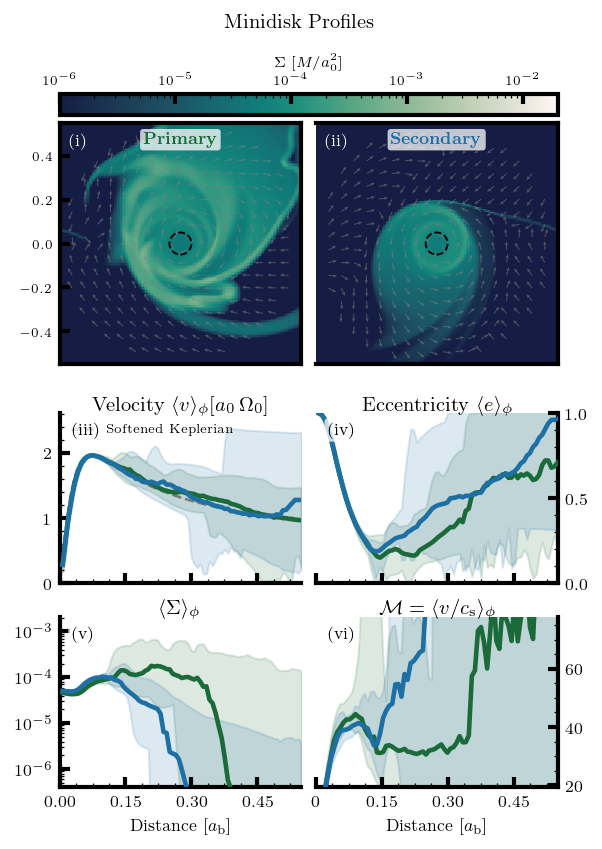

In [86]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

vlim            = 1.1 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxV']),  np.nanmax(SecondaryMiniDisk['MaxV'])])
dlim            = 3.0 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxD']),  np.nanmax(SecondaryMiniDisk['MaxD'])])
PrimaryRadius   = RadialBins_md[1:] #/ SinkRadius[0]
SecondaryRadius = RadialBins_md[1:] #/ SinkRadius[1]
xlim            = max(PrimaryRadius[-1], SecondaryRadius[-1])

_c_primary   = '#1B6B3A'
_c_secondary = '#1D6FA4'
_c_ref       = '#777777'

_sig_vals = np.concatenate([Sigma[primary_radius < RMinidisk].ravel(), Sigma[secondary_radius < RMinidisk].ravel()])
_sig_vals = _sig_vals[_sig_vals > 0]
_norm     = LogNorm(vmin=1e-6, vmax=2e-2)
_mach_all = np.concatenate([PrimaryMiniDisk['MedianM'], SecondaryMiniDisk['MedianM']])
_mac_max  = np.nanpercentile(_mach_all, 90) * 1.3
_mac_min  = 0.0

def _quiver_field(pos_x, pos_y, vel_x, vel_y):
    from scipy.interpolate import RegularGridInterpolator
    _nq   = 20
    _qgrd = np.linspace(-RMinidisk, RMinidisk, _nq)
    _qX, _qY = np.meshgrid(_qgrd, _qgrd)
    rgi_u = RegularGridInterpolator((y, x), vel_x, method='linear', bounds_error=False, fill_value=np.nan)
    rgi_v = RegularGridInterpolator((y, x), vel_y, method='linear', bounds_error=False, fill_value=np.nan)
    pts   = np.column_stack([(_qY + pos_y).ravel(), (_qX + pos_x).ravel()])
    U = rgi_u(pts).reshape(_nq, _nq)
    V = rgi_v(pts).reshape(_nq, _nq)
    R   = np.sqrt(_qX**2 + _qY**2)
    spd = np.sqrt(U**2 + V**2)
    spd[spd == 0] = np.nan
    U = np.where(R < RMinidisk, U / spd, np.nan)
    V = np.where(R < RMinidisk, V / spd, np.nan)
    return _qX, _qY, U, V

_qX_p, _qY_p, _qU_p, _qV_p = _quiver_field(primary.position_x,   primary.position_y,   Vx, Vy)
_qX_s, _qY_s, _qU_s, _qV_s = _quiver_field(secondary.position_x, secondary.position_y, Vx, Vy)

fig = plt.figure(figsize=(0.8*text_width, 1.12 * text_width), dpi=150)

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.93, top=0.925, bottom=0.609, wspace=0.06)
gs_bot = fig.add_gridspec(2, 2, left=0.10, right=0.93, top=0.565, bottom=0.12, hspace=0.20, wspace=0.06)

ax_pm  = fig.add_subplot(gs_top[0, 0])
ax_sm  = fig.add_subplot(gs_top[0, 1])
ax_vel = fig.add_subplot(gs_bot[0, 0])
ax_ecc = fig.add_subplot(gs_bot[0, 1])
ax_den = fig.add_subplot(gs_bot[1, 0])
ax_mac = fig.add_subplot(gs_bot[1, 1])

# --- (i, ii) density maps ---
for ax, pos_x, pos_y, title, c, sr, lbl, qX, qY, qU, qV in [
        (ax_pm, primary.position_x,   primary.position_y,   r'$\textbf{Primary}$',   _c_primary,   SinkRadius[0], 'i',  _qX_p, _qY_p, _qU_p, _qV_p),
        (ax_sm, secondary.position_x, secondary.position_y, r'$\textbf{Secondary}$', _c_secondary, SinkRadius[1], 'ii', _qX_s, _qY_s, _qU_s, _qV_s)]:
    im = ax.pcolormesh(X - pos_x, Y - pos_y, Sigma, cmap=cmocean.cm.tempo_r, norm=_norm, shading='auto', rasterized=True)
    ax.set_xlim([-RMinidisk, RMinidisk])
    ax.set_ylim([-RMinidisk, RMinidisk])
    ax.set_aspect('equal')
    ax.tick_params(which='both', direction='in', labelsize=6, bottom=False, labelbottom=False)
    ax.quiver(qX, qY, qU, qV, color='grey', alpha=0.55, scale=28, width=0.004, headwidth=3.5, headlength=4, headaxislength=3.5, zorder=4)
    ax.add_patch(Circle((0, 0), sr, fill=False, edgecolor='black', linewidth=0.9, linestyle='dashed', zorder=5))
    ax.text(0.50, 0.96, title, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='center', color=c, zorder=6, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(0.04, 0.96, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color='white', zorder=7)

#ax_pm.set_ylabel(r'$\Delta y\;[a_\mathrm{b}]$', fontsize=7)
ax_sm.tick_params(left=False, labelleft=False)
ax_sm.spines['left'].set_visible(False)



cax = fig.add_axes([0.10, 0.92, 0.83, 0.025])
cb  = fig.colorbar(im, cax=cax, orientation='horizontal', location='top')
#cb = fig.colorbar(im, ax=[ax_pm, ax_sm], location='top', shrink=1.0, pad=0.02, aspect=25)
cb.set_label(r'$\Sigma\;[M/a_0^2]$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# --- profile panel style ---
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

for ax in (ax_ecc, ax_mac):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

for ax in (ax_vel, ax_ecc):
    ax.tick_params(labelbottom=False)

for ax in (ax_den, ax_mac):
    ax.set_xlabel(r'Distance $[a_\mathrm{b}]$')

# shared xticks on all four profile panels
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.set_xticks([0, 0.15, 0.3, 0.45])

for ax, lbl in zip((ax_vel, ax_ecc, ax_den, ax_mac), ('iii', 'iv', 'v', 'vi')):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

ax_mac.set_xlim([0, xlim])

# --- (iii) Velocity ---
ax_vel.set_xlim([0, xlim])
ax_vel.set_ylim([0, vlim])
ax_vel.plot(PrimaryRadius,   PrimaryMiniDisk['MedianV'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_vel.plot(SecondaryRadius, SecondaryMiniDisk['MedianV'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_vel.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinV'],   PrimaryMiniDisk['MaxV'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_vel.fill_between(SecondaryRadius, SecondaryMiniDisk['MinV'], SecondaryMiniDisk['MaxV'], color=_c_secondary, alpha=0.15, zorder=1)
ax_vel.plot(PrimaryRadius, [r * np.sqrt(primary.mass / ((r**2 + SoftRadius[0]**2)**1.5)) for r in RadialBins_md[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label='Softened Keplerian', zorder=2)
ax_vel.legend(fontsize=6, frameon=False)
ax_vel.set_title(r'Velocity $\langle v \rangle_\phi[a_0\,\Omega_0]$', y=0.95)

# --- (iv) Eccentricity ---
ax_ecc.plot(PrimaryRadius,   PrimaryMiniDisk['MedianE'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_ecc.plot(SecondaryRadius, SecondaryMiniDisk['MedianE'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_ecc.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinE'],   PrimaryMiniDisk['MaxE'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_ecc.fill_between(SecondaryRadius, SecondaryMiniDisk['MinE'], SecondaryMiniDisk['MaxE'], color=_c_secondary, alpha=0.15, zorder=1)
ax_ecc.set_xlim([0, xlim])
ax_ecc.set_ylim([0, 1])
ax_ecc.set_yticks([0.0, 0.5, 1.0])
ax_ecc.set_title(r'Eccentricity $\langle e\rangle_\phi$', y=0.95)

# --- (v) Surface density ---
ax_den.plot(PrimaryRadius,   PrimaryMiniDisk['MedianD'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_den.plot(SecondaryRadius, SecondaryMiniDisk['MedianD'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_den.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinD'],   PrimaryMiniDisk['MaxD'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_den.fill_between(SecondaryRadius, SecondaryMiniDisk['MinD'], SecondaryMiniDisk['MaxD'], color=_c_secondary, alpha=0.15, zorder=1)
ax_den.set_xlim([0, xlim])
ax_den.set_ylim([dlim * 2e-4, dlim])
ax_den.set_yscale('log')
ax_den.set_title(r'$\langle\Sigma\rangle_\phi$', y=0.95)

# --- (vi) Mach ---
ax_mac.plot(PrimaryRadius,   PrimaryMiniDisk['MedianM'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_mac.plot(SecondaryRadius, SecondaryMiniDisk['MedianM'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_mac.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinM'],   PrimaryMiniDisk['MaxM'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_mac.fill_between(SecondaryRadius, SecondaryMiniDisk['MinM'], SecondaryMiniDisk['MaxM'], color=_c_secondary, alpha=0.15, zorder=1)
ax_mac.set_xlim([0, xlim])
ax_mac.set_xticklabels(['0', '0.15', '0.30', '0.45'])
ax_mac.set_ylim([np.min(DiskStats['MedianM'])/2, np.min([np.max(DiskStats['MedianM']), 2*np.min(DiskStats['MedianM'])])])
ax_mac.set_title(r'$\mathcal{M} = \langle v/c_\mathrm{s}\rangle_\phi$', y=0.95)

fig.suptitle('Minidisk Profiles', y=1.04)
plt.savefig(f"Minidisks_BG.png", dpi=400, bbox_inches='tight')

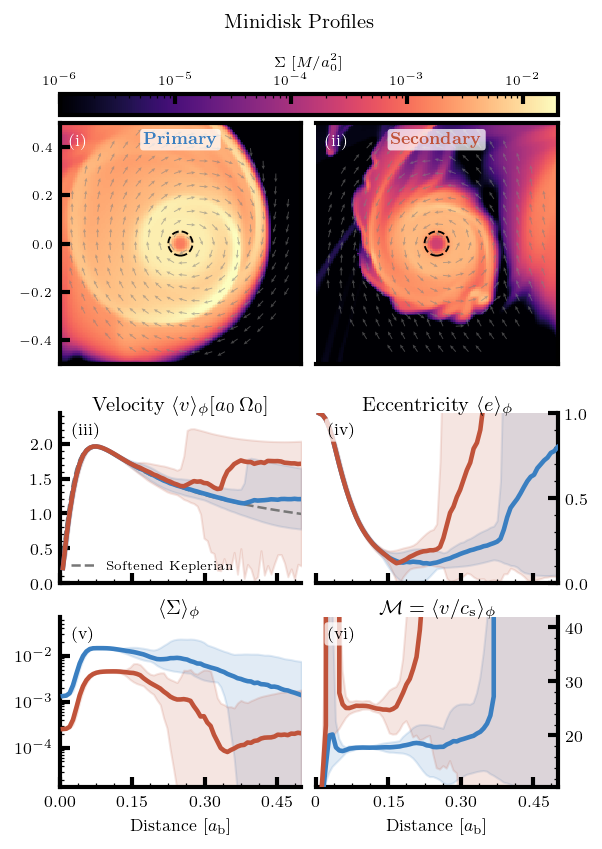

In [81]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

vlim            = 1.1 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxV']),  np.nanmax(SecondaryMiniDisk['MaxV'])])
dlim            = 3.0 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxD']),  np.nanmax(SecondaryMiniDisk['MaxD'])])
PrimaryRadius   = RadialBins_md[1:] #/ SinkRadius[0]
SecondaryRadius = RadialBins_md[1:] #/ SinkRadius[1]
xlim            = max(PrimaryRadius[-1], SecondaryRadius[-1])

_c_primary   = '#3A7FC1'
_c_secondary = '#C0533A'
_c_ref       = '#777777'

_sig_vals = np.concatenate([Sigma[primary_radius < RMinidisk].ravel(), Sigma[secondary_radius < RMinidisk].ravel()])
_sig_vals = _sig_vals[_sig_vals > 0]
_norm     = LogNorm(vmin=1e-6, vmax=2e-2)
_mach_all = np.concatenate([PrimaryMiniDisk['MeanM'], SecondaryMiniDisk['MeanM']])
_mac_max  = np.nanpercentile(_mach_all, 90) * 1.3
_mac_min  = 0.0

def _quiver_field(pos_x, pos_y, vel_x, vel_y):
    from scipy.interpolate import RegularGridInterpolator
    _nq   = 20
    _qgrd = np.linspace(-RMinidisk, RMinidisk, _nq)
    _qX, _qY = np.meshgrid(_qgrd, _qgrd)
    rgi_u = RegularGridInterpolator((y, x), vel_x, method='linear', bounds_error=False, fill_value=np.nan)
    rgi_v = RegularGridInterpolator((y, x), vel_y, method='linear', bounds_error=False, fill_value=np.nan)
    pts   = np.column_stack([(_qY + pos_y).ravel(), (_qX + pos_x).ravel()])
    U = rgi_u(pts).reshape(_nq, _nq)
    V = rgi_v(pts).reshape(_nq, _nq)
    R   = np.sqrt(_qX**2 + _qY**2)
    spd = np.sqrt(U**2 + V**2)
    spd[spd == 0] = np.nan
    U = np.where(R < RMinidisk, U / spd, np.nan)
    V = np.where(R < RMinidisk, V / spd, np.nan)
    return _qX, _qY, U, V

_qX_p, _qY_p, _qU_p, _qV_p = _quiver_field(primary.position_x,   primary.position_y,   Vx, Vy)
_qX_s, _qY_s, _qU_s, _qV_s = _quiver_field(secondary.position_x, secondary.position_y, Vx, Vy)

fig = plt.figure(figsize=(0.8*text_width, 1.12 * text_width), dpi=150)

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.93, top=0.925, bottom=0.609, wspace=0.06)
gs_bot = fig.add_gridspec(2, 2, left=0.10, right=0.93, top=0.565, bottom=0.12, hspace=0.20, wspace=0.06)

ax_pm  = fig.add_subplot(gs_top[0, 0])
ax_sm  = fig.add_subplot(gs_top[0, 1])
ax_vel = fig.add_subplot(gs_bot[0, 0])
ax_ecc = fig.add_subplot(gs_bot[0, 1])
ax_den = fig.add_subplot(gs_bot[1, 0])
ax_mac = fig.add_subplot(gs_bot[1, 1])

# --- (i, ii) density maps ---
for ax, pos_x, pos_y, title, c, sr, lbl, qX, qY, qU, qV in [
        (ax_pm, primary.position_x,   primary.position_y,   r'$\textbf{Primary}$',   _c_primary,   SinkRadius[0], 'i',  _qX_p, _qY_p, _qU_p, _qV_p),
        (ax_sm, secondary.position_x, secondary.position_y, r'$\textbf{Secondary}$', _c_secondary, SinkRadius[1], 'ii', _qX_s, _qY_s, _qU_s, _qV_s)]:
    im = ax.pcolormesh(X - pos_x, Y - pos_y, Sigma, cmap='magma', norm=_norm, shading='auto', rasterized=True)
    ax.set_xlim([-RMinidisk, RMinidisk])
    ax.set_ylim([-RMinidisk, RMinidisk])
    ax.set_aspect('equal')
    ax.tick_params(which='both', direction='in', labelsize=6, bottom=False, labelbottom=False)
    ax.quiver(qX, qY, qU, qV, color='grey', alpha=0.55, scale=28, width=0.004, headwidth=3.5, headlength=4, headaxislength=3.5, zorder=4)
    ax.add_patch(Circle((0, 0), sr, fill=False, edgecolor='black', linewidth=0.9, linestyle='dashed', zorder=5))
    ax.text(0.50, 0.96, title, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='center', color=c, zorder=6, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(0.04, 0.96, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color='white', zorder=7)

#ax_pm.set_ylabel(r'$\Delta y\;[a_\mathrm{b}]$', fontsize=7)
ax_sm.tick_params(left=False, labelleft=False)
ax_sm.spines['left'].set_visible(False)



cax = fig.add_axes([0.10, 0.92, 0.83, 0.025])
cb  = fig.colorbar(im, cax=cax, orientation='horizontal', location='top')
#cb = fig.colorbar(im, ax=[ax_pm, ax_sm], location='top', shrink=1.0, pad=0.02, aspect=25)
cb.set_label(r'$\Sigma\;[M/a_0^2]$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# --- profile panel style ---
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

for ax in (ax_ecc, ax_mac):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

for ax in (ax_vel, ax_ecc):
    ax.tick_params(labelbottom=False)

for ax in (ax_den, ax_mac):
    ax.set_xlabel(r'Distance $[a_\mathrm{b}]$')

# shared xticks on all four profile panels
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.set_xticks([0, 0.15, 0.3, 0.45])

for ax, lbl in zip((ax_vel, ax_ecc, ax_den, ax_mac), ('iii', 'iv', 'v', 'vi')):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

ax_mac.set_xlim([0, xlim])

# --- (iii) Velocity ---
ax_vel.set_xlim([0, xlim])
ax_vel.set_ylim([0, vlim])
ax_vel.plot(PrimaryRadius,   PrimaryMiniDisk['MeanV'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_vel.plot(SecondaryRadius, SecondaryMiniDisk['MeanV'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_vel.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinV'],   PrimaryMiniDisk['MaxV'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_vel.fill_between(SecondaryRadius, SecondaryMiniDisk['MinV'], SecondaryMiniDisk['MaxV'], color=_c_secondary, alpha=0.15, zorder=1)
ax_vel.plot(PrimaryRadius, [r * np.sqrt(primary.mass / ((r**2 + SoftRadius[0]**2)**1.5)) for r in RadialBins_md[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label='Softened Keplerian', zorder=2)
ax_vel.legend(fontsize=6, frameon=False)
ax_vel.set_title(r'Velocity $\langle v \rangle_\phi[a_0\,\Omega_0]$', y=0.95)

# --- (iv) Eccentricity ---
ax_ecc.plot(PrimaryRadius,   PrimaryMiniDisk['MeanE'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_ecc.plot(SecondaryRadius, SecondaryMiniDisk['MeanE'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_ecc.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinE'],   PrimaryMiniDisk['MaxE'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_ecc.fill_between(SecondaryRadius, SecondaryMiniDisk['MinE'], SecondaryMiniDisk['MaxE'], color=_c_secondary, alpha=0.15, zorder=1)
ax_ecc.set_xlim([0, xlim])
ax_ecc.set_ylim([0, 1])
ax_ecc.set_yticks([0.0, 0.5, 1.0])
ax_ecc.set_title(r'Eccentricity $\langle e\rangle_\phi$', y=0.95)

# --- (v) Surface density ---
ax_den.plot(PrimaryRadius,   PrimaryMiniDisk['MeanD'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_den.plot(SecondaryRadius, SecondaryMiniDisk['MeanD'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_den.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinD'],   PrimaryMiniDisk['MaxD'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_den.fill_between(SecondaryRadius, SecondaryMiniDisk['MinD'], SecondaryMiniDisk['MaxD'], color=_c_secondary, alpha=0.15, zorder=1)
ax_den.set_xlim([0, xlim])
ax_den.set_ylim([dlim * 2e-4, dlim])
ax_den.set_yscale('log')
ax_den.set_title(r'$\langle\Sigma\rangle_\phi$', y=0.95)

# --- (vi) Mach ---
ax_mac.plot(PrimaryRadius,   PrimaryMiniDisk['MeanM'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_mac.plot(SecondaryRadius, SecondaryMiniDisk['MeanM'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_mac.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinM'],   PrimaryMiniDisk['MaxM'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_mac.fill_between(SecondaryRadius, SecondaryMiniDisk['MinM'], SecondaryMiniDisk['MaxM'], color=_c_secondary, alpha=0.15, zorder=1)
ax_mac.set_xlim([0, xlim])
ax_mac.set_xticklabels(['0', '0.15', '0.30', '0.45'])
ax_mac.set_ylim([np.min(DiskStats['MeanM'])/2, np.min([np.max(DiskStats['MeanM']), 2*np.min(DiskStats['MeanM'])])])
ax_mac.set_title(r'$\mathcal{M} = \langle v/c_\mathrm{s}\rangle_\phi$', y=0.95)

fig.suptitle('Minidisk Profiles', y=1.04)
plt.savefig(f"Minidisks_OP.png", dpi=400, bbox_inches='tight')


## Accretion Timeseries

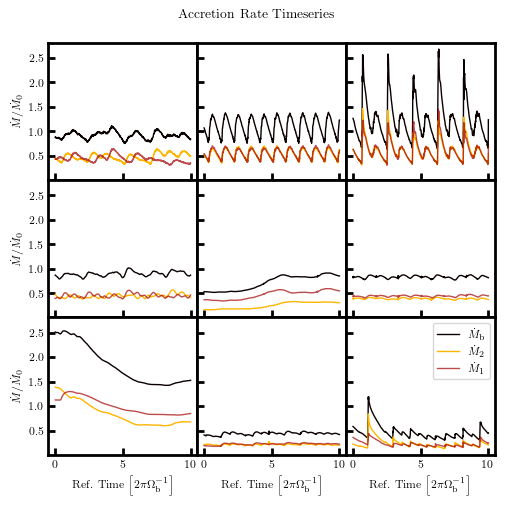

In [80]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]

    ts            = DavidTimeseries(data[Names[index]])
    SS73          = ts.SS73
    M_dot_0       = SS73.Mdot_inf
    cmap          = plt.cm.hot
    #chkpt  = data[Names[index]]
    #SS73   = chkpt["SS73"]
    #M_dot_0     = SS73.Mdot_inf

    Accretion_1   = -(np.array(ts.mdot1[-1000:])) / M_dot_0
    Accretion_2   = -(np.array(ts.mdot2[-1000:])) / M_dot_0
    AccretionRate = Accretion_1 + Accretion_2 

    Times = np.linspace(0, 10, 1000)
    ax.plot(Times, AccretionRate, label=r'$\dot{M}_\mathrm{b}$' , linewidth = 1.0, c = cmap(0.0/3)  )
    ax.plot(Times, Accretion_2  , label=r'$\dot{M}_2$'          , linewidth = 1.0, c = cmap(1.9/3))
    ax.plot(Times, Accretion_1  , label=r'$\dot{M}_1$'          , linewidth = 1.0, c = cmap(0.7/3), alpha = 0.7)
 
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

axes_flat[0].set_ylabel(r'$\dot{M} / \dot{M}_0$')
axes_flat[3].set_ylabel(r'$\dot{M} / \dot{M}_0$')
axes_flat[6].set_ylabel(r'$\dot{M} / \dot{M}_0$')

axes_flat[6].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')
axes_flat[7].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')
axes_flat[8].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')

axes_flat[8].legend()
fig.suptitle('Accretion Rate Timeseries', y=0.995)

plt.tight_layout()
plt.savefig('AccretionTimeseries.png', dpi=400)


## Shock Structure

In [ ]:
base_direct = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Fixed_e/'
aver_direct = ['e00Mach10/TimeAverages', 'e00Mach20/TimeAverages', 'e00Mach40/TimeAverages']

def time_averaged_FJ(run_dir, r_bins):
    files    = sorted(glob.glob(os.path.join(run_dir, 'chkpt.*.pk')))
    if not files:
        raise FileNotFoundError(f"No checkpoints in {run_dir}")

    chkpt0 = load_checkpoint(files[0])
    mesh   = chkpt0["mesh"]
    x      = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y      = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])

    profiles = []
    for f in files:
        chkpt = load_checkpoint(f)
        Sigma = chkpt["solution"][:, :, 0].T
        Vx    = chkpt["solution"][:, :, 1].T
        Vy    = chkpt["solution"][:, :, 2].T
        r_mid, FJ_r = compute_FJ_profile(Sigma, Vx, Vy, x, y, r_bins)
        profiles.append(FJ_r)

    profiles = np.array(profiles)
    return np.nanmean(profiles, axis=0), np.nanstd(profiles, axis=0), r_mid


def compute_FJ_profile(Sigma, Vx, Vy, x, y, r_bins):
    """Wave angular momentum flux F_J(r) = 2 pi r^2 <Sigma dvr dvphi>_phi."""
    X, Y = np.meshgrid(x, y)
    R    = np.sqrt(X**2 + Y**2)
    R    = np.where(R == 0, np.nan, R)

    Vr   = (X * Vx + Y * Vy) / R
    Vphi = (-Y * Vx + X * Vy) / R

    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])
    FJ_r  = np.full(len(r_mid), np.nan)

    for i, (r0, r1) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mask = (R >= r0) & (R < r1)
        if mask.sum() < 8:
            continue

        S   = Sigma[mask]
        vr  = Vr[mask]
        vp  = Vphi[mask]
        dvr = vr - np.average(vr, weights=S)
        dvp = vp - np.average(vp, weights=S)

        FJ_r[i] = 2 * np.pi * r_mid[i]**2 * np.mean(S * dvr * dvp)

    return r_mid, FJ_r


FJ_mean = []
FJ_std  = []
r_mid   = []
r_bins  = np.linspace(0.15, 3.0, 50)
for index in range(3):
    
    # --- Time-averaged alpha profile ---
    ax_prof   = prof_axes[index]
    run_dir   = base_direct + aver_direct[index]
    
    FJ_mean_axis, FJ_std_axis, r_mid_axis = time_averaged_FJ(run_dir, r_bins)
    FJ_mean.append(FJ_mean_axis)
    FJ_std.append(FJ_std_axis)
    r_mid.append(r_mid_axis)


Save = True
if Save:
    np.save('FJ_mean.npy', np.array(FJ_mean))
    np.save('FJ_std.npy',  np.array(FJ_std))
    np.save('r_mid.npy',   np.array(r_mid))

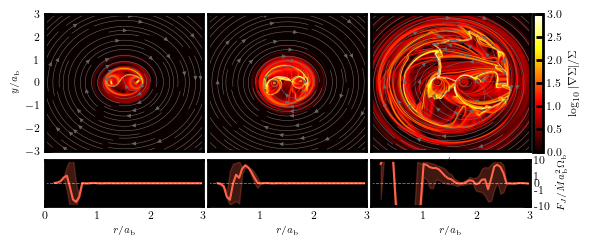

In [ ]:
Load = False
if Load:
    FJ_mean = np.load('FJ_mean.npy')
    FJ_std  = np.load('FJ_std.npy')
    r_mid   = np.load('r_mid.npy')


fig = plt.figure(figsize=(1.25* text_width, 0.6 * text_width), dpi=100)

gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[3, 1],
    hspace=0.1,
    wspace=0.03,
)

map_axes  = [fig.add_subplot(gs[0, i]) for i in range(3)]  # top row
prof_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]  # bottom row



for index in range(3):
    ax      = map_axes[index]
    ax_prof = prof_axes[index]
    chkpt   = data[Names[3 * index]]

    mesh  = chkpt["mesh"]
    SS73  = chkpt["SS73"]
    Sigma = chkpt["solution"][:, :, 0].T 
    Vx    = chkpt["solution"][:, :, 1].T
    Vy    = chkpt["solution"][:, :, 2].T
    x     = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y     = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])

    # --- Schlieren map (single snapshot) ---
    dS_dx = np.gradient(Sigma, x, axis=1)
    dS_dy = np.gradient(Sigma, y, axis=0)
    f     = np.sqrt(dS_dx**2 + dS_dy**2) / Sigma

    ax.streamplot(x, y, Sigma * Vx, Sigma * Vy, density=2.5, color='dimgray', linewidth=0.4, arrowsize=0.6)
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm = ax.imshow(np.log10(f), origin="lower", vmin=0.0, vmax=3.0, cmap='hot', extent=extent)
    ax.set_xlim(-3.0, 3.0)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('auto')

    
    ax_prof.plot(r_mid[index], FJ_mean[index]/SS73.Mdot_inf, color='tomato', linewidth=1.5)
    ax_prof.fill_between(r_mid[index], (FJ_mean[index] - FJ_std[index])/SS73.Mdot_inf, (FJ_mean[index] + FJ_std[index])/SS73.Mdot_inf, color='tomato', alpha=0.25)
    ax_prof.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.5)
    ax_prof.set_ylim([-10, 10])
    ax_prof.set_yscale('symlog')

    ax_prof.set_xlim(0, 3.0)
    ax_prof.set_xlabel(r'$r / a_\mathrm{b}$', fontsize=7)
    ax_prof.set_facecolor('black')
    ax_prof.set_yticks([])
    ax_prof.set_xticks([])

ax_prof.yaxis.tick_right()

map_axes[0].set_ylabel(r'$y / a_\mathrm{b}$', fontsize=7)
map_axes[0].yaxis.set_major_locator(MultipleLocator(1))

prof_axes[0].set_xticks([0, 1, 2, 3]); prof_axes[0].set_xticklabels(['0', '1', '2', '3'])
prof_axes[1].set_xticks([1, 2, 3]); prof_axes[1].set_xticklabels(['1', '2', '3'])
prof_axes[2].set_xticks([1, 2, 3]); prof_axes[2].set_xticklabels(['1', '2', '3'])

ax_prof.set_ylabel(r'$\frac{2\pi r^2\langle \Sigma \delta v_r \delta v_\phi \rangle/_\phi}{dot{M} a_\mathrm{b}^2\Omega_\mathrm{b}}$', fontsize=7)
ax_prof.yaxis.set_label_position('right')

cax = fig.add_axes([0.906, 0.3275, 0.015, 0.5525])   # [left, bottom, width, height]
fig.colorbar(cm, cax=cax, label=r'$\log_{10}|\nabla\Sigma|/\Sigma$')
ax_prof.set_yticks([-10, -1, 0, 1, 10])
ax_prof.set_yticklabels(['-10', -1, 0, 1, 10])
ax.set_xlabel(r'$x / a_\mathrm{b}$', fontsize=7)

fig.suptitle('Shock-Driven Angular Momentum Transport')
plt.savefig('ShockEfficiency.png', dpi = 400, bbox_inches='tight')
